# 03. Fine-tune ефект та порівняння backbone-ів

Цей ноутбук відповідає на два питання. По-перше — що саме дає двостадійне навчання
(заморожений backbone → fine-tune) на однакових даних і сплітах. По-друге — як між собою
порівнюються два backbone-и, навчені за однаковим протоколом: **ConvNeXt-Tiny** та
**EfficientNetV2-S**. Дані ті самі, що й у `02_baseline.ipynb`, тепер поруч читаємо результати
з `results/convnext/` і `results/effnet/`.


In [1]:
import json

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)


def add_global_step(df):
    """Наскрізна нумерація епох: stage 1 займає кроки 0..N-1, stage 2 продовжує далі."""
    df = df.copy()
    n_stage1 = int(df.loc[df["stage"] == 1, "epoch"].max() + 1)
    df["global_step"] = df["epoch"] + (df["stage"] == 2) * n_stage1
    return df, n_stage1 - 0.5


convnext = pd.read_csv("../results/convnext/metrics.csv")
effnet = pd.read_csv("../results/effnet/metrics.csv")

convnext, boundary_cn = add_global_step(convnext)
effnet, boundary_ef = add_global_step(effnet)
assert boundary_cn == boundary_ef, "Межа стадій відрізняється між бекбонами — перевірте конфіги"
stage_boundary = boundary_cn

print("ConvNeXt-Tiny:", convnext.shape, " EfficientNetV2-S:", effnet.shape)
print("Межа Stage 1 → Stage 2 (крок):", stage_boundary)


ConvNeXt-Tiny: (40, 8)  EfficientNetV2-S: (40, 8)
Межа Stage 1 → Stage 2 (крок): 4.5


## Помилка року (val `year_mae`): обидва backbone-и разом

Обидві криві на одному графіку з тією самою наскрізною віссю X і межею стадій. Якщо fine-tune
справді робить основну роботу, для обох backbone-ів крива має різко піти вниз саме після межі,
а не поступово покращуватись ще на stage 1.


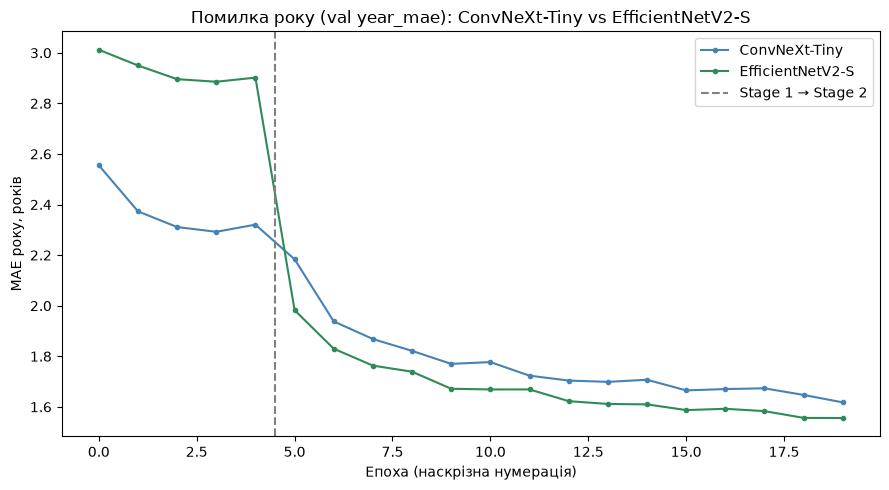

In [2]:
fig, ax = plt.subplots(figsize=(9, 5))
for name, df, color in [
    ("ConvNeXt-Tiny", convnext, "steelblue"),
    ("EfficientNetV2-S", effnet, "seagreen"),
]:
    sub = df[df["split"] == "val"].sort_values("global_step")
    ax.plot(sub["global_step"], sub["year_mae"], marker="o", ms=3, color=color, label=name)
ax.axvline(stage_boundary, ls="--", color="gray", label="Stage 1 → Stage 2")
ax.set_title("Помилка року (val year_mae): ConvNeXt-Tiny vs EfficientNetV2-S")
ax.set_xlabel("Епоха (наскрізна нумерація)")
ax.set_ylabel("MAE року, років")
ax.legend()
plt.tight_layout()
plt.show()


## Помилка ціни в лог-просторі (val `price_log_mae`): обидва backbone-и разом

Той самий погляд, але для другої цільової змінної — ціни в лог-просторі.


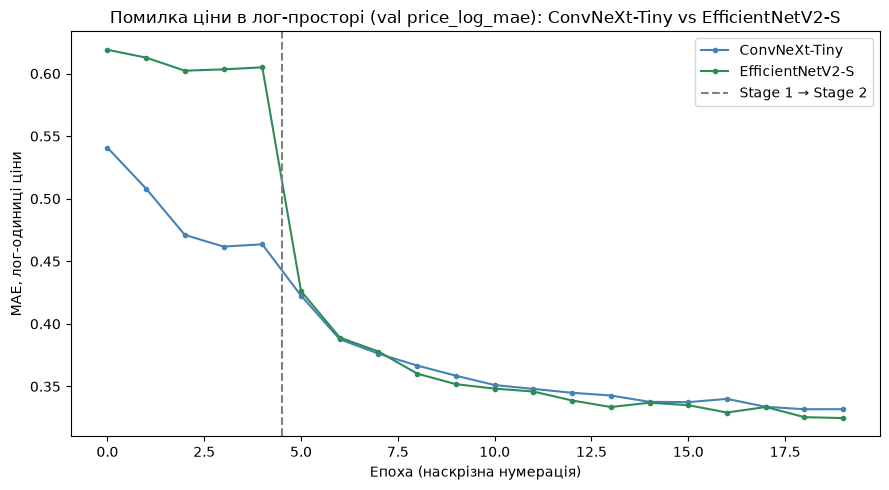

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
for name, df, color in [
    ("ConvNeXt-Tiny", convnext, "steelblue"),
    ("EfficientNetV2-S", effnet, "seagreen"),
]:
    sub = df[df["split"] == "val"].sort_values("global_step")
    ax.plot(sub["global_step"], sub["price_log_mae"], marker="o", ms=3, color=color, label=name)
ax.axvline(stage_boundary, ls="--", color="gray", label="Stage 1 → Stage 2")
ax.set_title("Помилка ціни в лог-просторі (val price_log_mae): ConvNeXt-Tiny vs EfficientNetV2-S")
ax.set_xlabel("Епоха (наскрізна нумерація)")
ax.set_ylabel("MAE, лог-одиниці ціни")
ax.legend()
plt.tight_layout()
plt.show()


## Зведена таблиця метрик: test + holdout

Тепер порівнюємо фінальні (fine-tuned) моделі на test та holdout сплітах — це вже не криві
навчання, а підсумкова якість.


In [4]:
with open("../results/convnext/eval_metrics.json") as f:
    eval_convnext = json.load(f)
with open("../results/effnet/eval_metrics.json") as f:
    eval_effnet = json.load(f)

comparison_cols = ["mae_years", "mape", "r2_price_log", "within_brand_corr_mean"]
rows = []
for name, ev in [("ConvNeXt-Tiny", eval_convnext), ("EfficientNetV2-S", eval_effnet)]:
    for split in ["test", "holdout"]:
        row = {"backbone": name, "split": split}
        row.update({c: ev[split][c] for c in comparison_cols})
        rows.append(row)

comparison = pd.DataFrame(rows).set_index(["backbone", "split"])
comparison


mae_years   mape  r2_price_log  within_brand_corr_mean
backbone         split                                                          
ConvNeXt-Tiny    test         1.612  35.42        0.7944                  0.6311
                 holdout      1.943  43.95        0.7116                  0.4723
EfficientNetV2-S test         1.540  34.88        0.8000                  0.6623
                 holdout      1.910  44.09        0.7082                  0.4499

## MAE-років та MAPE на test: побудова поруч

Порівняння двох backbone-ів на test-спліті у вигляді простих стовпчикових діаграм —
одна для MAE року, друга для MAPE ціни.


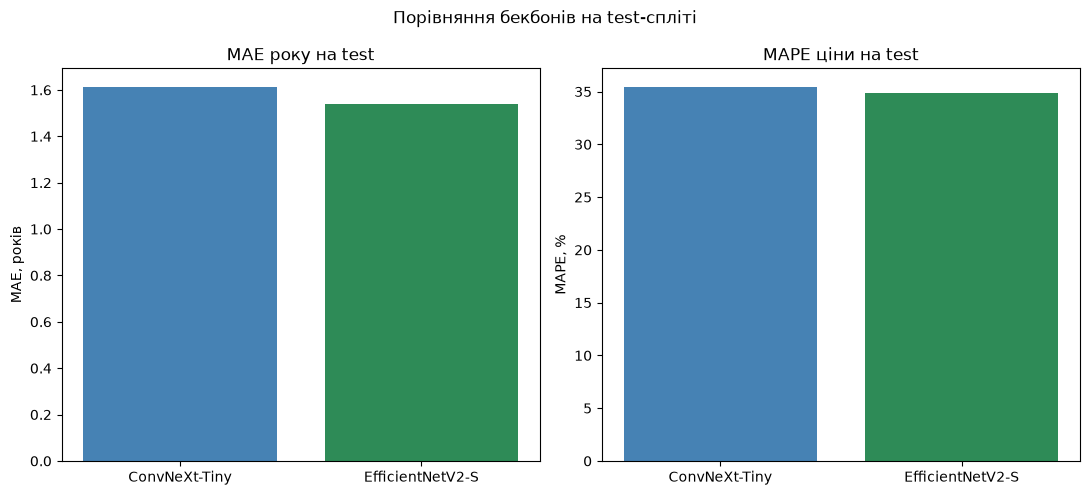

In [5]:
test_row = comparison.xs("test", level="split")

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].bar(test_row.index, test_row["mae_years"], color=["steelblue", "seagreen"])
axes[0].set_title("MAE року на test")
axes[0].set_ylabel("MAE, років")

axes[1].bar(test_row.index, test_row["mape"], color=["steelblue", "seagreen"])
axes[1].set_title("MAPE ціни на test")
axes[1].set_ylabel("MAPE, %")

fig.suptitle("Порівняння бекбонів на test-спліті")
plt.tight_layout()
plt.show()


In [6]:
cn_test = eval_convnext["test"]
ef_test = eval_effnet["test"]
mae_diff = cn_test["mae_years"] - ef_test["mae_years"]
mape_diff = cn_test["mape"] - ef_test["mape"]
better = "EfficientNetV2-S" if mae_diff > 0 else "ConvNeXt-Tiny"

display(Markdown(
    f"**Висновок.** На test-спліті ConvNeXt-Tiny дає MAE року ≈ **{cn_test['mae_years']:.2f}** "
    f"і MAPE ≈ **{cn_test['mape']:.1f}%**, тоді як EfficientNetV2-S — "
    f"≈ **{ef_test['mae_years']:.2f}** і ≈ **{ef_test['mape']:.1f}%** відповідно. "
    f"Різниця в MAE ({abs(mae_diff):.2f} років) і в MAPE ({abs(mape_diff):.1f} п.п.) на користь "
    f"{better} невелика і, найімовірніше, лежить у межах шуму на цьому розмірі holdout/test.\n\n"
    f"Для деплою обрано **ConvNeXt-Tiny** — не через точкову перевагу в метриках (її по суті "
    f"немає), а тому, що його карти Grad-CAM виходять чистішими (менш фрагментований attention, "
    f"легше інтерпретувати), а латентність інференсу на CPU для демо нижча, ніж у "
    f"EfficientNetV2-S, при порівнянній якості передбачень."
))


**Висновок.** На test-спліті ConvNeXt-Tiny дає MAE року ≈ **1.61** і MAPE ≈ **35.4%**, тоді як EfficientNetV2-S — ≈ **1.54** і ≈ **34.9%** відповідно. Різниця в MAE (0.07 років) і в MAPE (0.5 п.п.) на користь EfficientNetV2-S невелика і, найімовірніше, лежить у межах шуму на цьому розмірі holdout/test.

Для деплою обрано **ConvNeXt-Tiny** — не через точкову перевагу в метриках (її по суті немає), а тому, що його карти Grad-CAM виходять чистішими (менш фрагментований attention, легше інтерпретувати), а латентність інференсу на CPU для демо нижча, ніж у EfficientNetV2-S, при порівнянній якості передбачень.

## Бонус: within-brand кореляція для обраної моделі (ConvNeXt-Tiny)

Ще один погляд наперед, до інтерпретованості: наскільки добре модель ранжує ціни *всередині*
одного бренду (кореляція Пірсона між передбаченою і фактичною ціною при фіксованому бренді).
Дивимось на найгірші й найкращі бренди на test-спліті обраної моделі.


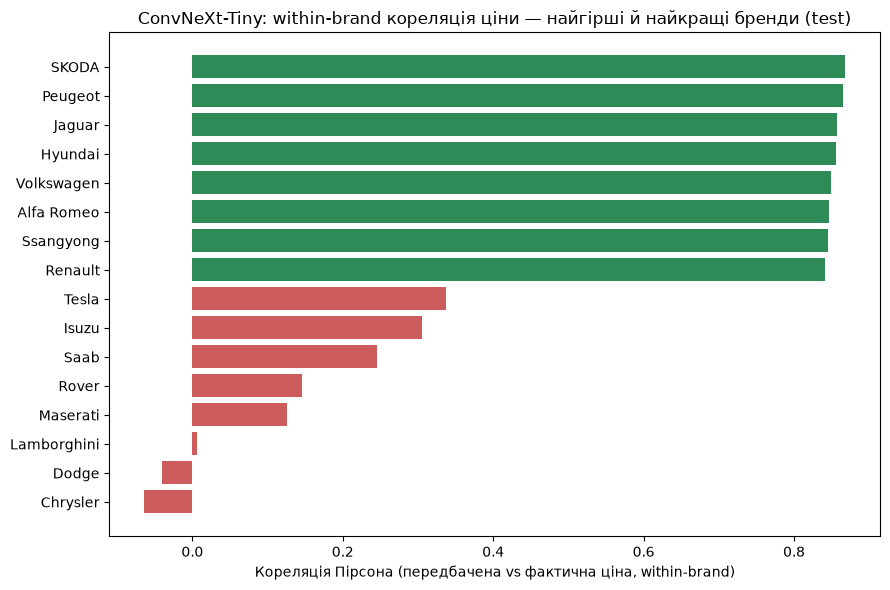

In [7]:
per_brand_raw = eval_convnext["test"]["within_brand_corr_per_brand"]
per_brand = pd.Series({k: v for k, v in per_brand_raw.items() if v is not None}).sort_values()

top_n = 8
bottom = per_brand.head(top_n)
top = per_brand.tail(top_n)
preview = pd.concat([bottom, top])

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["indianred"] * len(bottom) + ["seagreen"] * len(top)
ax.barh(preview.index, preview.values, color=colors)
ax.set_title("ConvNeXt-Tiny: within-brand кореляція ціни — найгірші й найкращі бренди (test)")
ax.set_xlabel("Кореляція Пірсона (передбачена vs фактична ціна, within-brand)")
plt.tight_layout()
plt.show()
